## Produces **Mosquito Predictions** for a specific region using MAMOTH ##

In [6]:
import pandas as pd
import datetime
import math
import numpy as np
import missingno
import json
from statistics import mean
import re
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import KNNImputer
import sys

sys.path.insert(0, "../../../Mamoth Modules")
sys.path.insert(0, "../../../Modules")

from preprocessing_utils import *

from Preprocessing_Module import read_data, select_columns, reshape_dataset
from Initializer_Module import initializer
from Neural_Network_Module import Dataset, transformations, FeedforwardNeuralNetModel, train_nn, give_predictions
from Model_Validation_Module import validation_plots, metrics

enc = 'utf-8'

pd.options.display.max_columns = None
pd.options.display.max_rows = 10

In [7]:
import warnings
warnings.filterwarnings('ignore')

In [8]:
NUTS0 = 'IT'
NUTS2 = 'Veneto'
NUTS2_LOWER = 'veneto'

In [9]:
YEAR = 2023
MONTH = 'August'
PERIOD = '1st'

In [10]:
dataset = pd.read_csv(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_Timeline_{YEAR}-{MONTH}-{PERIOD}_filled.csv', encoding=enc)

In [11]:
dataset.head()

,lau1,region,x,y,dt_placement,year,month,indices_image_date,indices_lat,indices_lon,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,monthly_lst_lat,monthly_lst_lon,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,indices_image_date.1,indices_lat.1,indices_lon.1,acc_rainfall_jan,dt_placement_minus_7,dt_placement_minus_14,dt_placement_minus_7_avail,dt_placement_minus_14_avail,acc_rainfall_1week,acc_rainfall_2week
0,abano terme,veneto,11.79539,45.35783,2023-08-01,2023,8,2023-07-29,45.358184,11.797125,0.330288,0.054089,-0.306413,-0.054089,0.382274,0.206532,-0.282201,-0.206532,0.084187,0.097709,0.088017,0.097709,NaN,NaN,45.358184,11.797125,14038.800000,13687.500000,14061.500000,13617.923077,14575.785714,13973.818182,14732.538462,14005.000000,2023-07-29,45.350207,11.750054,1297.380891,2023-07-25,2023-07-18,2023-07-25,2023-07-18,26.144866,220.360543
1,adria,veneto,12.03247,45.07647,2023-08-01,2023,8,2023-07-29,45.075215,12.030687,0.328549,0.190629,-0.283486,-0.190629,0.328549,0.190629,-0.283486,-0.190629,0.000000,0.000000,0.000000,0.000000,NaN,NaN,45.075215,12.030687,13945.400000,13748.500000,14071.181818,13559.142857,14500.214286,13855.642857,14757.400000,13934.300000,2023-07-29,45.050206,12.050055,1496.479402,2023-07-25,2023-07-18,2023-07-25,2023-07-18,8.177698,103.445441
2,adria,veneto,12.05787,45.05851,2023-08-01,2023,8,2023-07-29,45.057249,12.057637,0.200000,-0.081700,-0.230088,0.081700,0.301219,-0.006119,-0.302495,0.006119,0.116910,0.087426,0.086403,0.087426,NaN,NaN,45.057249,12.057637,14027.875000,13725.500000,14072.000000,13638.083333,14514.416667,13929.000000,14743.785714,13989.000000,2023-07-29,45.050206,12.050055,1496.479402,2023-07-25,2023-07-18,2023-07-25,2023-07-18,8.177698,103.445441
3,adria,veneto,12.05787,45.07647,2023-08-01,2023,8,2023-07-29,45.075215,12.057637,0.435404,0.072342,-0.418443,-0.072342,0.540113,0.169260,-0.490827,-0.169260,0.114002,0.119819,0.083366,0.119819,NaN,NaN,45.075215,12.057637,13962.750000,13738.142857,14045.700000,13574.000000,14485.384615,13873.500000,14705.133333,13907.700000,2023-07-29,45.050206,12.050055,1496.479402,2023-07-25,2023-07-18,2023-07-25,2023-07-18,8.177698,103.445441
4,affi,veneto,10.77673,45.55680,2023-08-01,2023,8,2023-07-29,45.555814,10.777538,0.309802,0.097396,-0.304298,-0.097396,0.470080,0.149377,-0.415465,-0.149377,0.146330,0.065925,0.110579,0.065925,NaN,NaN,45.555814,10.777538,13948.583333,13694.400000,14089.076923,13693.533333,14517.882353,13856.687500,14603.421053,14001.444444,2023-07-29,45.550208,10.750049,1226.564601,2023-07-25,2023-07-18,2023-07-25,2023-07-18,2.875075,568.898263


In [12]:
dataset.rename(columns={"region": "nuts2"}, inplace=True)

In [13]:
cols = dataset.columns
cols

Index(['lau1', 'nuts2', 'x', 'y', 'dt_placement', 'year', 'month',
       'indices_image_date', 'indices_lat', 'indices_lon', 'ndvi', 'ndmi',
       'ndwi', 'ndbi', 'ndvi_mean', 'ndmi_mean', 'ndwi_mean', 'ndbi_mean',
       'ndvi_std', 'ndmi_std', 'ndwi_std', 'ndbi_std', 'lst_day', 'lst_night',
       'monthly_lst_lat', 'monthly_lst_lon', 'lst_jan_day_mean',
       'lst_jan_night_mean', 'lst_feb_day_mean', 'lst_feb_night_mean',
       'lst_mar_day_mean', 'lst_mar_night_mean', 'lst_apr_day_mean',
       'lst_apr_night_mean', 'indices_image_date.1', 'indices_lat.1',
       'indices_lon.1', 'acc_rainfall_jan', 'dt_placement_minus_7',
       'dt_placement_minus_14', 'dt_placement_minus_7_avail',
       'dt_placement_minus_14_avail', 'acc_rainfall_1week',
       'acc_rainfall_2week'],
      dtype='object')

In [14]:
dataset.drop(columns=['indices_image_date', 'indices_lat', 'indices_lon' , 'lst_image_date', 'lst_lat','lst_lon' ,'monthly_lst_lat', 'monthly_lst_lon', 
                         'indices_image_date.1', 'indices_lat.1', 'indices_lon.1', 'dt_placement_minus_7', 'dt_placement_minus_14', 'dt_placement_minus_7_avail',
                         'dt_placement_minus_14_avail'], inplace = True)

KeyError: "['lst_image_date', 'lst_lat', 'lst_lon'] not found in axis"

In [ ]:
dataset = dataset.rename(columns=lambda x: re.sub('_new', '', x))

In [11]:
dataset.head(5)

,lau1,nuts2,x,y,dt_placement,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_jan,acc_rainfall_1week,acc_rainfall_2week
0,abano terme,veneto,11.79539,45.35783,2023-07-16,2023,7,0.314886,0.047775,-0.299570,-0.047775,0.374255,0.075818,-0.347207,-0.075818,0.072728,0.044203,0.053912,0.044203,15349.0,14663.0,14036.375000,13697.666667,14061.500000,13617.923077,14574.769231,13982.000000,14732.538462,14005.000000,365.508363,6.413500,34.178536
1,adria,veneto,12.03247,45.07647,2023-07-16,2023,7,0.354124,0.065375,-0.374427,-0.065375,0.417833,0.117365,-0.407913,-0.117365,0.084402,0.094864,0.054051,0.094864,15177.0,14545.0,13924.375000,13752.800000,14071.181818,13559.142857,14506.750000,13868.692308,14745.500000,13934.300000,614.292642,7.656067,40.872501
2,adria,veneto,12.05787,45.05851,2023-07-16,2023,7,0.198639,-0.042642,-0.221333,0.042642,0.266976,0.000836,-0.273315,-0.000836,0.066890,0.050795,0.051250,0.050795,15258.0,14576.0,14018.166667,13711.800000,14072.000000,13638.083333,14510.727273,13940.769231,14732.461538,13989.000000,614.292642,7.656067,40.872501
3,adria,veneto,12.05787,45.07647,2023-07-16,2023,7,0.328839,0.027236,-0.342857,-0.027236,0.409854,0.101623,-0.396952,-0.101623,0.092418,0.096543,0.061782,0.096543,15195.0,14529.0,13942.000000,13738.333333,14045.700000,13574.000000,14485.454545,13886.923077,14697.000000,13907.700000,614.292642,7.656067,40.872501
4,affi,veneto,10.77673,45.55680,2023-07-16,2023,7,0.339500,0.064362,-0.324926,-0.064362,0.461000,0.129956,-0.409306,-0.129956,0.110138,0.055805,0.084224,0.055805,15087.0,14557.0,13972.222222,13697.857143,14089.076923,13693.533333,14516.500000,13870.071429,14575.470588,14001.444444,234.700794,6.402151,74.657804


In [12]:
grouped = dataset.groupby(['dt_placement', 'lau1', 'nuts2'], as_index = False)
dataset = grouped.mean()
dataset

,dt_placement,lau1,nuts2,x,y,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_jan,acc_rainfall_1week,acc_rainfall_2week
0,2023-07-16,abano terme,veneto,11.795390,45.357830,2023.0,7.0,0.314886,0.047775,-0.299570,-0.047775,0.374255,0.075818,-0.347207,-0.075818,0.072728,0.044203,0.053912,0.044203,15349.0,14663.0,14036.375000,13697.666667,14061.500000,13617.923077,14574.769231,13982.000000,14732.538462,14005.000000,365.508363,6.413500,34.178536
1,2023-07-16,adria,veneto,12.049403,45.070483,2023.0,7.0,0.293867,0.016656,-0.312873,-0.016656,0.364888,0.073274,-0.359393,-0.073274,0.081237,0.080734,0.055694,0.080734,15210.0,14550.0,13961.513889,13734.311111,14062.960606,13590.408730,14500.977273,13898.794872,14724.987179,13943.666667,614.292642,7.656067,40.872501
2,2023-07-16,affi,veneto,10.776730,45.556800,2023.0,7.0,0.339500,0.064362,-0.324926,-0.064362,0.461000,0.129956,-0.409306,-0.129956,0.110138,0.055805,0.084224,0.055805,15087.0,14557.0,13972.222222,13697.857143,14089.076923,13693.533333,14516.500000,13870.071429,14575.470588,14001.444444,234.700794,6.402151,74.657804
3,2023-07-16,agna,veneto,11.965390,45.175310,2023.0,7.0,0.318698,0.033828,-0.317368,-0.033828,0.421128,0.123635,-0.395117,-0.123635,0.108539,0.093933,0.085156,0.093933,15213.0,14569.0,13874.500000,13686.750000,14045.111111,13555.769231,14457.333333,13878.888889,14720.230769,13913.461538,599.293707,7.009414,22.983486
4,2023-07-16,agordo,veneto,12.059120,46.313990,2023.0,7.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
566,2023-07-16,zevio,veneto,11.127335,45.353970,2023.0,7.0,0.422196,0.094430,-0.377826,-0.094430,0.458362,0.172400,-0.403601,-0.172400,0.054944,0.058881,0.042940,0.058881,15169.5,14623.5,13976.444444,13611.633929,14099.275000,13581.468750,14606.142857,13901.145455,14722.108333,13993.187500,283.742224,6.280569,31.074402
567,2023-07-16,zimella,veneto,11.358050,45.347770,2023.0,7.0,0.682290,0.384645,-0.588056,-0.384645,0.602264,0.296295,-0.539806,-0.296295,0.094027,0.110762,0.058663,0.110762,15201.0,14555.0,13930.500000,13658.500000,14134.750000,13579.470588,14627.352941,13914.700000,14812.846154,13957.700000,274.319462,6.081703,34.237711
568,2023-07-16,zoppe da cadore,veneto,12.178780,46.388350,2023.0,7.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000
569,2023-07-16,zovencedo,veneto,11.494300,45.437980,2023.0,7.0,0.682373,0.285089,-0.567844,-0.285089,0.672487,0.266746,-0.563673,-0.266746,0.014126,0.016971,0.012478,0.016971,14973.0,14558.0,13943.416667,13727.714286,14065.416667,13746.400000,14413.875000,13990.727273,14519.125000,13987.400000,253.544025,4.418517,30.723389


In [13]:
dataset['dt_placement'] = pd.to_datetime(dataset['dt_placement'])

In [14]:
dataset['day'] = dataset['dt_placement'].apply(lambda x : x.day)
dataset['week'] = dataset.apply(lambda row: datetime.date(int(row['year']), int(row['month']), int(row['day'])).isocalendar().week, axis=1)

In [15]:
dataset = encode_cyclical(dataset, 'day', 31)
dataset = encode_cyclical(dataset, 'month', 12)
dataset = encode_cyclical(dataset, 'week', 53)

<AxesSubplot:>

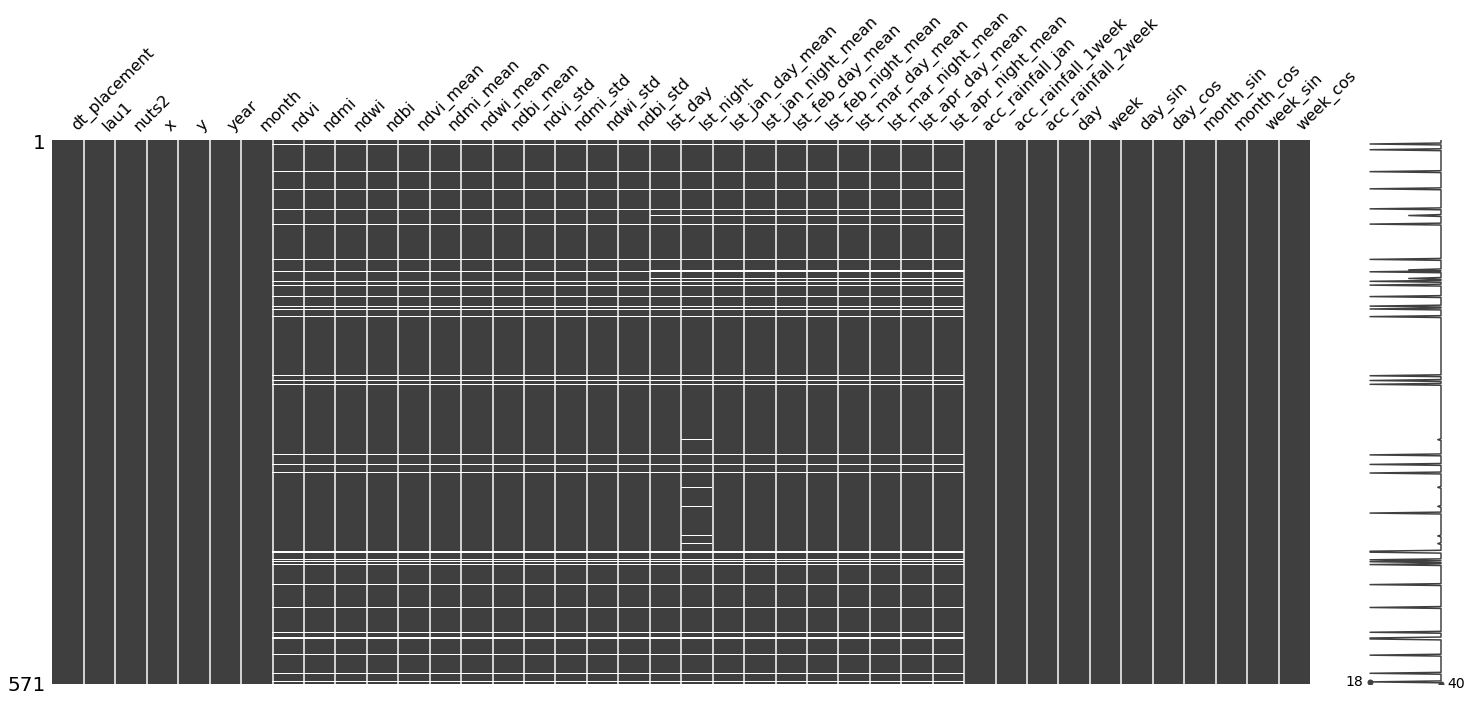

In [16]:
missingno.matrix(dataset)

In [17]:
mosquito_data = read_data(f'../../data/{NUTS0}_MSQ_culex_2010-2022_processed.csv')

Index(['nuts2', 'x', 'y', 'dt_placement', 'day', 'month', 'week', 'year',
       'day_sin', 'day_cos', 'month_sin', 'month_cos', 'week_sin', 'week_cos',
       'ndvi', 'ndwi', 'ndmi', 'ndbi', 'ndvi_mean', 'ndvi_std', 'ndwi_mean',
       'ndwi_std', 'ndmi_mean', 'ndmi_std', 'ndbi_mean', 'ndbi_std', 'lst_day',
       'lst_night', 'lst_jan_mean', 'lst_feb_mean', 'lst_mar_mean',
       'lst_apr_mean', 'acc_rainfall_1week', 'acc_rainfall_2week',
       'acc_rainfall_jan', 'wc_mean_dist_1000', 'coast_mean_dist_1000',
       'dem_mean_1km', 'slope_mean_1km', 'aspect_mean_1km', 'waw_mean_1km',
       'flow_accu_1km', 'mosq_now'],
      dtype='object')


In [18]:
mosquito_data.nuts2.unique()

array(['Veneto', 'Lombardia', 'Firuli-Venezia-Giulia',
       'Friuli-Venezia-Giulia'], dtype=object)

In [19]:
mosquito_data_nuts2 = mosquito_data.query("nuts2 == 'Veneto'").copy()
mosquito_data_nuts2.reset_index(inplace = True, drop = True)

In [20]:
mosq_columns = mosquito_data_nuts2.columns
mosq_columns

Index(['nuts2', 'x', 'y', 'dt_placement', 'day', 'month', 'week', 'year',
       'day_sin', 'day_cos', 'month_sin', 'month_cos', 'week_sin', 'week_cos',
       'ndvi', 'ndwi', 'ndmi', 'ndbi', 'ndvi_mean', 'ndvi_std', 'ndwi_mean',
       'ndwi_std', 'ndmi_mean', 'ndmi_std', 'ndbi_mean', 'ndbi_std', 'lst_day',
       'lst_night', 'lst_jan_mean', 'lst_feb_mean', 'lst_mar_mean',
       'lst_apr_mean', 'acc_rainfall_1week', 'acc_rainfall_2week',
       'acc_rainfall_jan', 'wc_mean_dist_1000', 'coast_mean_dist_1000',
       'dem_mean_1km', 'slope_mean_1km', 'aspect_mean_1km', 'waw_mean_1km',
       'flow_accu_1km', 'mosq_now'],
      dtype='object')

In [21]:
columns_to_keep = ['x', 'y', 'dt_placement', 'day', 'month', 'week', 'year',
                'day_sin', 'day_cos', 'month_sin', 'month_cos', 'week_sin', 'week_cos',
                'ndvi', 'ndwi', 'ndmi', 'ndbi', 'ndvi_mean', 'ndvi_std', 'ndwi_mean',
                'ndwi_std', 'ndmi_mean', 'ndmi_std', 'ndbi_mean', 'ndbi_std', 'lst_day',
                'lst_night', 'lst_jan_mean', 'lst_feb_mean', 'lst_mar_mean',
                'lst_apr_mean', 'acc_rainfall_1week', 'acc_rainfall_2week',
                'acc_rainfall_jan', 'mosq_now']

mosquito_data_nuts2 = select_columns(mosquito_data_nuts2, columns_to_keep, columns_to_keep)

mosquito_data_nuts2 = reshape_dataset(mosquito_data_nuts2,['x','y','dt_placement'])

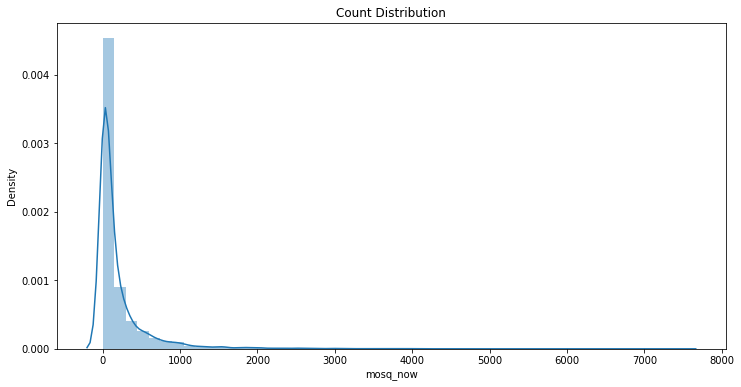

In [22]:
plt.figure(figsize=(12,6))
sns.distplot(mosquito_data_nuts2['mosq_now'])
plt.title('Count Distribution')
plt.show()

In [23]:
#quantile might change based on sns plots
mosq_quantilie = mosquito_data_nuts2['mosq_now'].quantile(0.90)

mosquito_data_nuts2['mosq_now'][mosquito_data_nuts2['mosq_now'] > mosq_quantilie] = mosq_quantilie+1

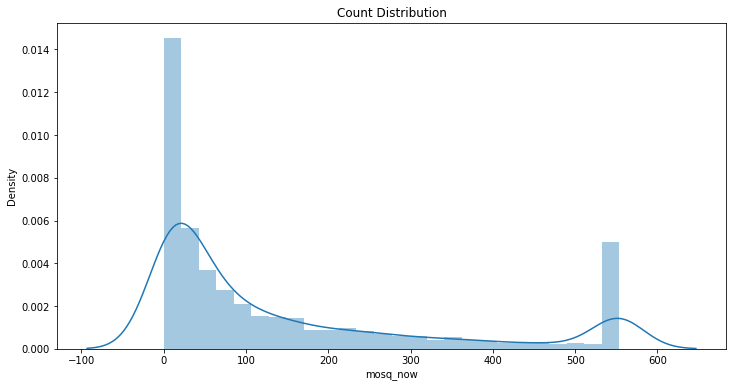

In [24]:
plt.figure(figsize=(12,6))
sns.distplot(mosquito_data_nuts2['mosq_now'])
plt.title('Count Distribution')
plt.show()

<AxesSubplot:>

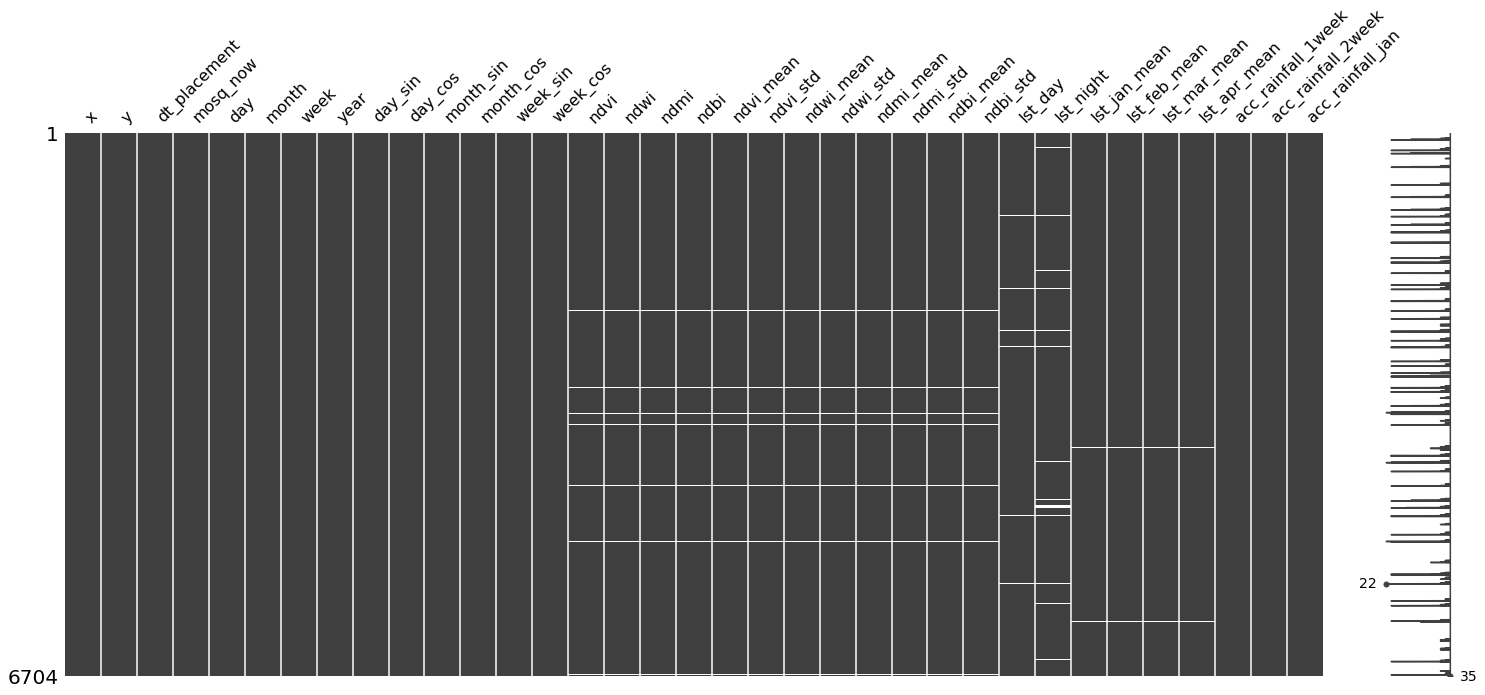

In [25]:
missingno.matrix(mosquito_data_nuts2)

In [26]:
imputer = KNNImputer()

features_for_impute = ['x', 'y', 'day', 'month', 'week', 'year', 'day_sin', 'day_cos', 'month_sin', 'month_cos', 'week_sin', 'week_cos',
                        'ndvi', 'ndwi', 'ndmi', 'ndbi', 'ndvi_mean', 'ndvi_std', 'ndwi_mean', 'ndwi_std', 'ndmi_mean', 'ndmi_std', 'ndbi_mean', 'ndbi_std', 
                        'lst_day', 'lst_night', 'lst_jan_mean', 'lst_feb_mean', 'lst_mar_mean', 'lst_apr_mean', 'acc_rainfall_1week', 'acc_rainfall_2week', 'acc_rainfall_jan']

mosquito_data_sub = mosquito_data_nuts2[features_for_impute]

imputed_data = pd.DataFrame(imputer.fit_transform(mosquito_data_sub), columns = mosquito_data_sub.columns)

In [27]:
imputed_columns = ['ndvi','ndmi', 'ndwi', 'ndbi','ndvi_mean','ndmi_mean','ndwi_mean','ndbi_mean','ndvi_std', 'ndmi_std','ndwi_std','ndbi_std',
                   'lst_day','lst_night','lst_jan_mean','lst_feb_mean','lst_mar_mean','lst_apr_mean']

mosquito_data_nuts2[imputed_columns] = imputed_data[imputed_columns]

<AxesSubplot:>

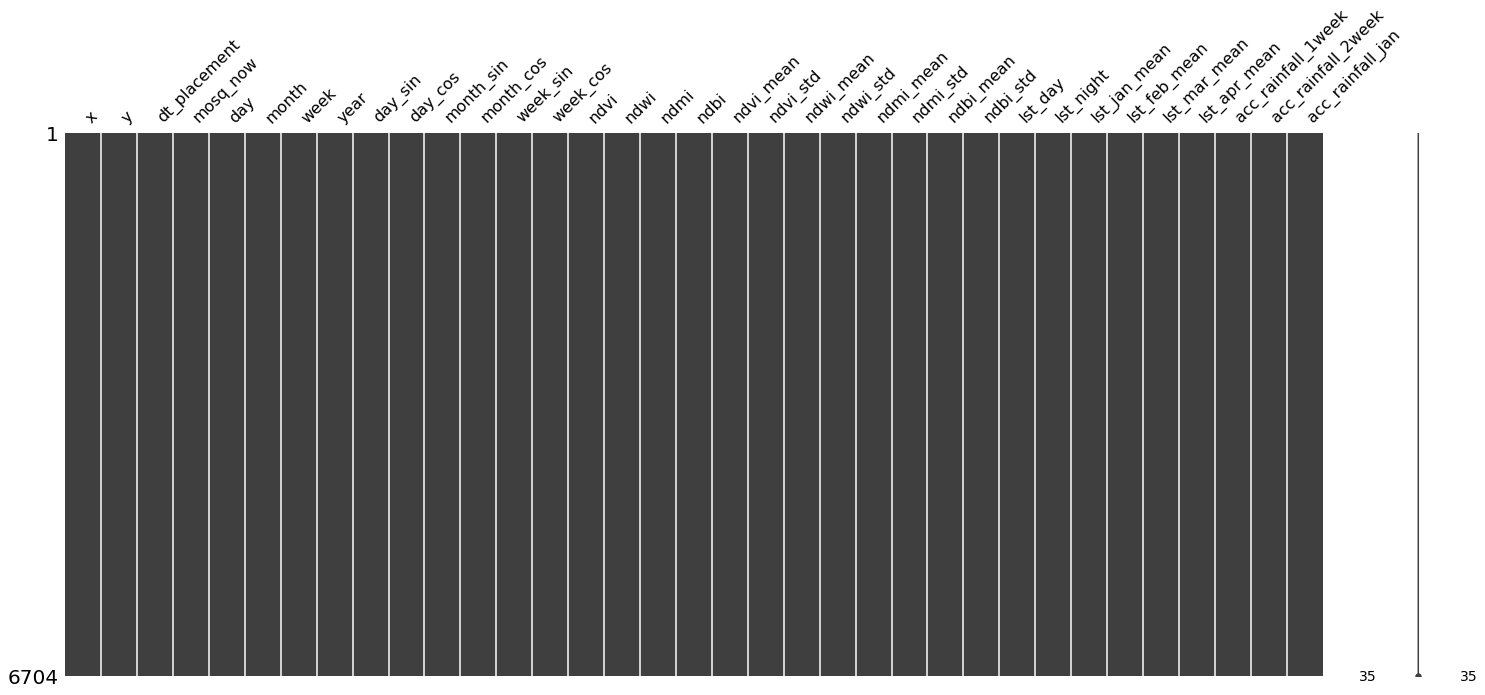

In [28]:
missingno.matrix(mosquito_data_nuts2)

In [29]:
step = 15
only_env = True
case_title = 'NN mosq regression'
exp = False
date_col = 'dt_placement'
model_type = 'mosquito_regression'
transform_target = True
augment = True

In [30]:
mosquito_data_nuts2 = initializer(mosquito_data_nuts2,2,10,25,step,[date_col], env=only_env, date_column = date_col, mosq_column='mosq_now')

Bounds: [  0.   61.  553.7]


In [31]:
train_X, train_y, test_X, test_y, scaler = transformations(mosquito_data_nuts2, model_type = model_type, split = 0.25, augment=augment)

training_set = Dataset(train_X, train_y, model_type=model_type, transform = transform_target)
testing_set = Dataset(test_X, test_y, model_type=model_type, transform = transform_target)

model = FeedforwardNeuralNetModel(num_features=len(train_X[0]), num_class=1, hidden_layers = [264,128,128,64], dropout=0.2, model_type=model_type, transform = transform_target)

Epoch 001: | Train Loss: 7.68284 | Val Loss: 4.79591 | Train Acc: 1.985| Val Acc: 1.330
Epoch 002: | Train Loss: 5.96196 | Val Loss: 4.73420 | Train Acc: 1.628| Val Acc: 1.360
Epoch 003: | Train Loss: 5.76839 | Val Loss: 4.44734 | Train Acc: 1.587| Val Acc: 1.286
Epoch 004: | Train Loss: 5.68321 | Val Loss: 4.63386 | Train Acc: 1.556| Val Acc: 1.332
Epoch 005: | Train Loss: 5.35865 | Val Loss: 4.61383 | Train Acc: 1.485| Val Acc: 1.310
Epoch 006: | Train Loss: 5.00497 | Val Loss: 4.25574 | Train Acc: 1.443| Val Acc: 1.216
Epoch 007: | Train Loss: 5.11392 | Val Loss: 3.93765 | Train Acc: 1.467| Val Acc: 1.129
Epoch 008: | Train Loss: 4.99623 | Val Loss: 4.11240 | Train Acc: 1.416| Val Acc: 1.175
Epoch 009: | Train Loss: 4.85905 | Val Loss: 4.07323 | Train Acc: 1.406| Val Acc: 1.159
Epoch 010: | Train Loss: 4.65537 | Val Loss: 4.11900 | Train Acc: 1.360| Val Acc: 1.143
Epoch 011: | Train Loss: 4.62246 | Val Loss: 4.01869 | Train Acc: 1.358| Val Acc: 1.098
Epoch 012: | Train Loss: 4.67400

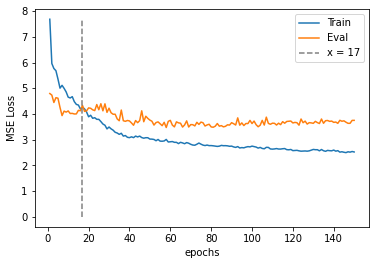

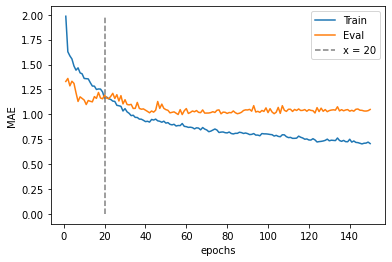

In [32]:
train, test, model = train_nn(model = model, learning_rate = 0.005, epochs = 150, batch_size = 128, train_set = training_set, test_set = testing_set, early_stop = False)

In [33]:
metrics(train, test, threshold=30)

MAE on train set:  83.45691053014374
min prediction: 1
max prediction: 645

MAE on test set:  91.51065899279432
Error ⩽ 30: 37.06 %
min prediction: 1
max prediction: 644


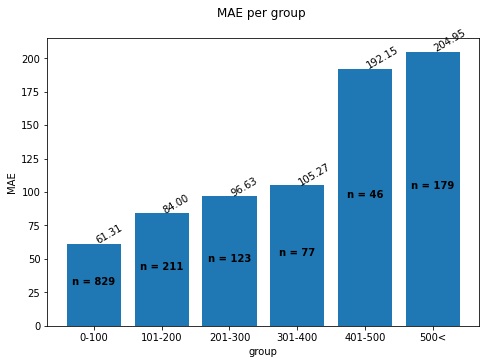

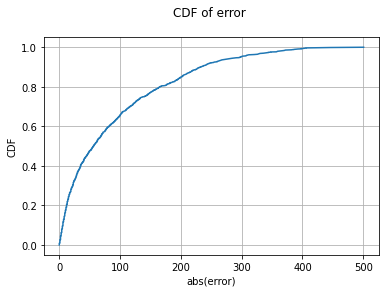

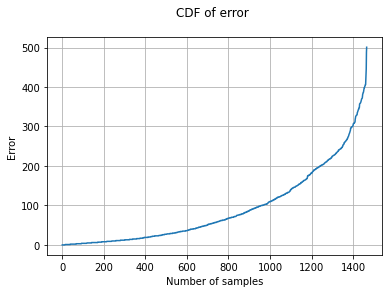

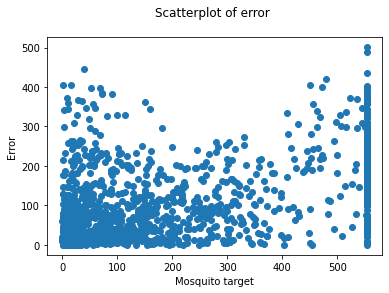

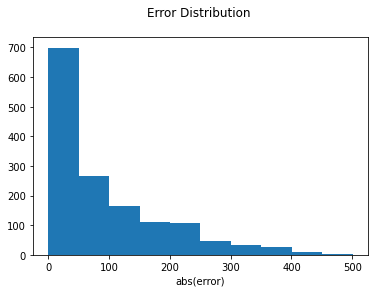

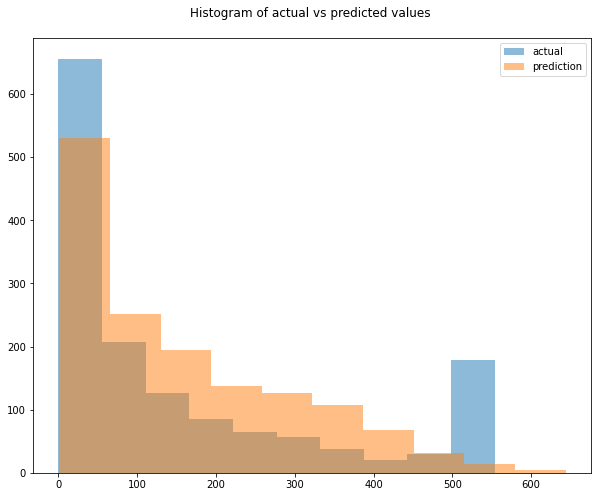

In [34]:
validation_plots(test,model_type)

Epoch 001: | Train Loss: 2.81418 | Val Loss: 0.31546 | Train Acc: 0.839| Val Acc: 0.394
Epoch 002: | Train Loss: 2.70494 | Val Loss: 0.19759 | Train Acc: 0.832| Val Acc: 0.394
Epoch 003: | Train Loss: 2.72911 | Val Loss: 0.32195 | Train Acc: 0.832| Val Acc: 0.394
Epoch 004: | Train Loss: 2.73976 | Val Loss: 0.39982 | Train Acc: 0.834| Val Acc: 0.394
Epoch 005: | Train Loss: 2.71694 | Val Loss: 0.37458 | Train Acc: 0.829| Val Acc: 0.394
Epoch 006: | Train Loss: 2.75037 | Val Loss: 0.52218 | Train Acc: 0.850| Val Acc: 0.394
Epoch 007: | Train Loss: 2.70886 | Val Loss: 0.15289 | Train Acc: 0.846| Val Acc: 0.394
Epoch 008: | Train Loss: 2.71190 | Val Loss: 0.22128 | Train Acc: 0.843| Val Acc: 0.394
Epoch 009: | Train Loss: 2.67124 | Val Loss: 0.88877 | Train Acc: 0.840| Val Acc: 1.394
Epoch 010: | Train Loss: 2.61290 | Val Loss: 0.87860 | Train Acc: 0.810| Val Acc: 1.394
Epoch 011: | Train Loss: 2.62853 | Val Loss: 1.31886 | Train Acc: 0.811| Val Acc: 1.394
Epoch 012: | Train Loss: 2.63532

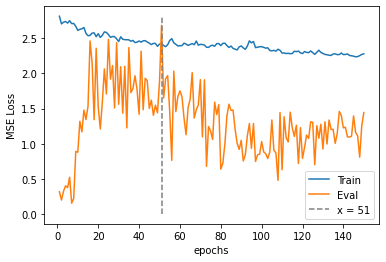

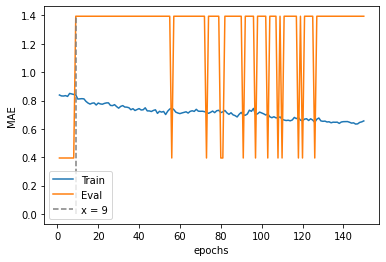

In [35]:
train_X, train_y, test_X, test_y, scaler = transformations(mosquito_data_nuts2, model_type = model_type, split = 0.000001, augment=augment)

training_set = Dataset(train_X, train_y, model_type=model_type, transform = transform_target)
testing_set = Dataset(test_X, test_y, model_type=model_type, transform = transform_target)

train, test, model = train_nn(model = model, learning_rate = 0.005, epochs = 150, batch_size = 128, train_set = training_set, test_set = testing_set, early_stop = False)

In [36]:
dataset_mamoth = dataset_mamoth_preparation(dataset, columns_to_keep)

In [37]:
mosqutio_predictions = dataset_mamoth[['x', 'y', 'dt_placement']].copy()

In [38]:
dataset_mamoth.drop(columns=['dt_placement'], inplace=True)

In [39]:
dataset_mamoth_sub = dataset_mamoth[features_for_impute]

In [40]:
mamoth_imputed = pd.DataFrame(imputer.transform(dataset_mamoth_sub), columns = dataset_mamoth_sub.columns)

In [41]:
dataset_mamoth[features_for_impute] = mamoth_imputed[features_for_impute]

<AxesSubplot:>

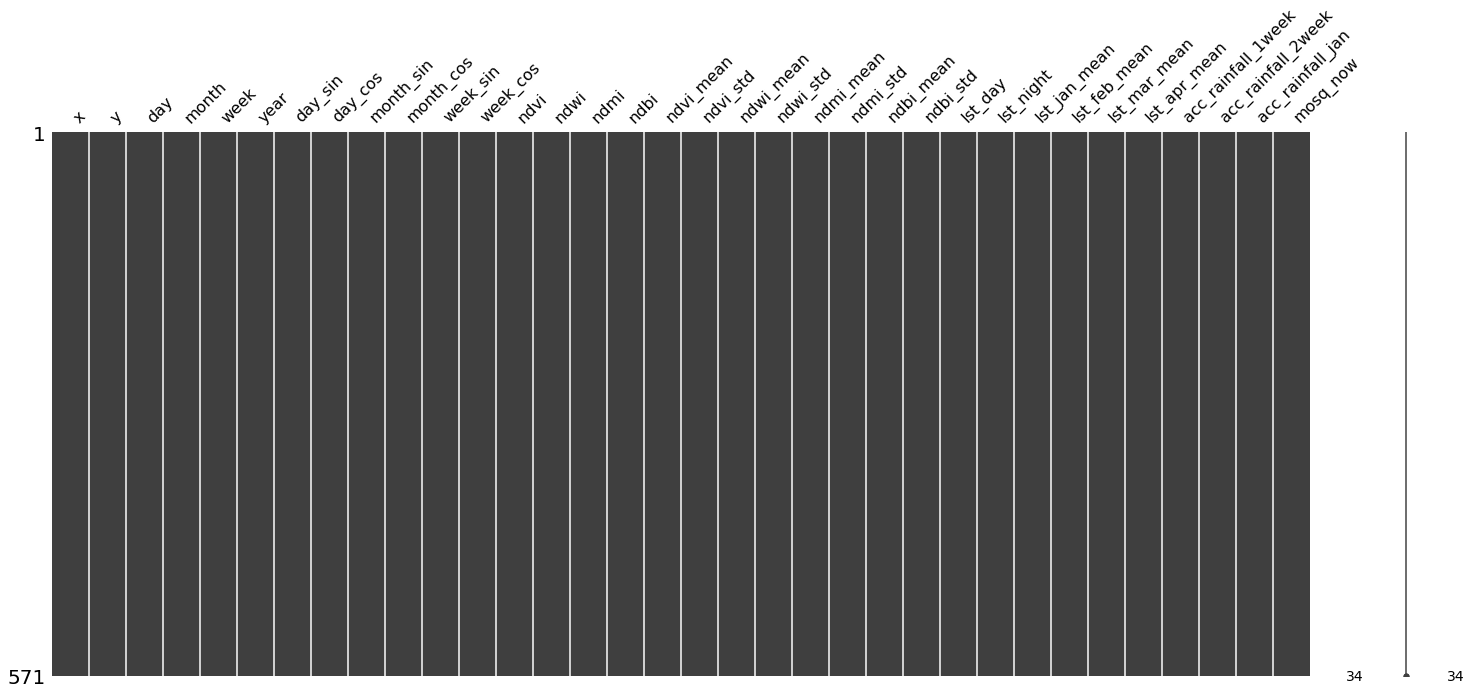

In [42]:
missingno.matrix(dataset_mamoth)

In [43]:
dataset_mamoth_X, dataset_mamoth_y = dataset_mamoth.iloc[:,:-1], dataset_mamoth.iloc[:,-1]

dataset_mamoth_X = scaler.transform(dataset_mamoth_X)

In [44]:
dataset_mamoth = Dataset(dataset_mamoth_X, dataset_mamoth_y, model_type=model_type, transform = transform_target)

In [45]:
predictions = give_predictions(model, dataset_mamoth)

In [46]:
mosqutio_predictions['mosq_pred'] = predictions

In [47]:
mosqutio_predictions

,x,y,dt_placement,mosq_pred
0,11.795390,45.357830,2023-07-16,54
1,12.049403,45.070483,2023-07-16,161
2,10.776730,45.556800,2023-07-16,29
3,11.965390,45.175310,2023-07-16,146
4,12.059120,46.313990,2023-07-16,20
...,...,...,...,...
566,11.127335,45.353970,2023-07-16,166
567,11.358050,45.347770,2023-07-16,329
568,12.178780,46.388350,2023-07-16,19
569,11.494300,45.437980,2023-07-16,198


In [48]:
mosqutio_predictions.to_csv(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_Culex_Predictions_{YEAR}-{MONTH}-{PERIOD}.csv', index = False)